# Train a joint 4-class U-Net (road + building + point) with PLEMMultiTaskLoss

This is the **new-loss arm** of the CE+Dice-vs-new-loss ablation described in `PAPER_OUTLINE.md`
(§9.5/§10.5): `train_unet.ipynb` is frozen as the 3-class (background/road/building), plain
CE+soft-Dice **baseline**; this notebook trains the same `SmallUNet` backbone (now `models/unet.py`,
extracted so both notebooks share the identical architecture -- otherwise the two runs would risk
architecture drift, invalidating the comparison) extended to 4 classes (adding **point**), using
`losses/PLEMMultiTaskLoss` -- a differentiable multi-task loss combining a soft tolerance-band term
(DTAF1 analog), a soft-clDice term (clDice analog), and a point-heatmap regression term (Point-F1
analog, reformulated) -- on a **joint SpaceNet+Potsdam** training source, since neither dataset
alone annotates all three feature types (SpaceNet: road+building, no point; Potsdam: building+
point, no road).

**Scope caveat, matching `train_unet.ipynb`'s own framing:** this is a pipeline sanity check --
"does the whole train -> predict -> score -> inspect loop work end-to-end with a genuinely joint
4-class model and the new multi-task loss" -- not a tuned extractor or a benchmark-scale ablation.
The training set is even smaller and more heterogeneous than the baseline's (~100 SpaceNet tiles
plus only ~15 Potsdam crops, at two different GSDs, not resampled to a common one -- see
`datasets/joint.py`'s docstring and `PAPER_OUTLINE.md` §9.5/§11), and epoch count is reduced
relative to the baseline to keep this CPU-only run's wall-clock time reasonable. Expect modest,
noisy scores -- the point is mechanical correctness (all four loss sub-terms actually decrease,
both sources appear in training batches, `point_classes` flows all the way through
`evaluate_all()` on real data), not headline numbers.

## Colab setup (skipped automatically when running locally)

Same pattern as `train_unet.ipynb`. This notebook additionally needs the **Potsdam** cache
(`data/potsdam`, built with `extract_buildings=True` by `potsdam_data_prep.ipynb`) alongside the
SpaceNet cache -- Potsdam needs a one-time, user-side Kaggle API token
(`~/.kaggle/kaggle.json`, see `potsdam_data_prep.ipynb`'s prerequisite section), which this cell
cannot set up on your behalf. If it's missing, the cache-check cell below prints a clear
instruction rather than failing silently deep inside training.

In [1]:
import sys, os, subprocess

IN_COLAB = "google.colab" in sys.modules

if IN_COLAB:
    REPO_URL = "https://github.com/DanielZGeorge/PLEM.git"
    REPO_DIR = "/content/PLEM"

    if not os.path.isdir(REPO_DIR):
        subprocess.run(["git", "clone", REPO_URL, REPO_DIR], check=True)
    else:
        subprocess.run(["git", "-C", REPO_DIR, "pull"], check=True)

    subprocess.run(
        [sys.executable, "-m", "pip", "install", "-q",
         "scikit-image", "networkx", "rasterio", "shapely", "kaggle"],
        check=True,
    )

    os.chdir(f"{REPO_DIR}/notebooks")
    print(f"Colab detected -- repo ready at {REPO_DIR}, cwd set to {os.getcwd()}")
else:
    print("Not running in Colab -- skipping repo clone/dependency install.")

Not running in Colab -- skipping repo clone/dependency install.


In [2]:
import sys, os, random
from pathlib import Path
sys.path.insert(0, os.path.abspath(".."))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from torch.utils.data import Dataset, DataLoader

from metrics import evaluate_all
from models.unet import SmallUNet
from losses.multitask import PLEMMultiTaskLoss
from datasets.joint import load_joint_tiles, class_mask_for_source, SOURCE_CLASSES, NUM_CLASSES

DATA_DIR = Path("..").resolve() / "data"
MODELS_DIR = Path("..").resolve() / "models"
MODELS_DIR.mkdir(exist_ok=True)

SEED = 0
PATCH = 256
DEVICE = torch.device("cpu")  # CPU-only by design, matches train_unet.ipynb
if torch.cuda.is_available():
    print("NOTE: CUDA is available but unused -- this notebook always trains on CPU.")

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

CLASS_NAMES = {0: "background", 1: "road", 2: "building", 3: "point"}


def overlay4(label):
    """Color-code a 4-class label map: road red, building green, point yellow."""
    o = np.zeros((*label.shape, 3), dtype=np.uint8)
    o[label == 1] = [255, 0, 0]
    o[label == 2] = [0, 255, 0]
    o[label == 3] = [255, 255, 0]
    return o

### Auto-build the SpaceNet + Potsdam caches on Colab if missing

Mirrors `train_unet.ipynb`'s SpaceNet auto-build cell, extended to also build Potsdam. The Potsdam
branch needs a Kaggle token (see above) -- if missing, this prints instructions and continues with
SpaceNet-only data rather than crashing (the notebook still runs, just without the point class
represented in training, which is itself a useful degenerate-case check).

In [3]:
if IN_COLAB:
    if not os.path.isdir(DATA_DIR / "spacenet") or not any((DATA_DIR / "spacenet").iterdir()):
        from datasets.spacenet import build_spacenet_sample
        CITIES = ["Vegas", "Khartoum", "Paris", "Shanghai"]
        print("data/spacenet is empty -- building the curated SpaceNet sample (a few minutes)...")
        for city in CITIES:
            build_spacenet_sample(city, n_tiles=25, n_road_candidates=100,
                                   cache_dir=str(DATA_DIR / "spacenet" / city), seed=0)

    if not os.path.isdir(DATA_DIR / "potsdam") or not any((DATA_DIR / "potsdam").iterdir()):
        try:
            from datasets.potsdam import load_kaggle_dataset, build_potsdam_sample
            load_kaggle_dataset(dest=str(DATA_DIR / "potsdam_raw"))
            build_potsdam_sample(
                n_crops=15, seed=0, cache_dir=str(DATA_DIR / "potsdam"),
                raw_dir=str(DATA_DIR / "potsdam_raw"), extract_buildings=True,
            )
        except Exception as e:
            print(f"Could not build the Potsdam cache automatically ({e}). "
                  f"Set up ~/.kaggle/kaggle.json (see potsdam_data_prep.ipynb) and re-run this "
                  f"cell, or continue with SpaceNet-only data (no point class in training).")

## Load tiles and split train/val/test (per source, then concatenate)

`load_joint_tiles()` loads every cached SpaceNet tile (road+building) and Potsdam tile
(building+point), tagging each with its `source` and `class_mask`. Each source is split 70/15/15
**independently** at the tile level before concatenating -- a single pooled-then-permuted split
risks an unlucky seed starving the much smaller Potsdam side (only ~15 crops) from a split
entirely. A quick per-split source-count printout confirms both sources actually land in every
split.

In [4]:
def split_tiles(tiles, seed=SEED):
    rng = np.random.default_rng(seed)
    perm = rng.permutation(len(tiles))
    n = len(tiles)
    n_train = int(round(0.70 * n))
    n_val = int(round(0.15 * n))
    train = [tiles[i] for i in perm[:n_train]]
    val = [tiles[i] for i in perm[n_train:n_train + n_val]]
    test = [tiles[i] for i in perm[n_train + n_val:]]
    return train, val, test


all_tiles = load_joint_tiles(spacenet_dir=DATA_DIR / "spacenet", potsdam_dir=DATA_DIR / "potsdam")
by_source = {}
for t in all_tiles:
    by_source.setdefault(t["source"], []).append(t)
print(f"Loaded {len(all_tiles)} tiles: " + ", ".join(f"{k}={len(v)}" for k, v in by_source.items()))

train_tiles, val_tiles, test_tiles = [], [], []
for source, tiles in by_source.items():
    tr, va, te = split_tiles(tiles, seed=SEED)
    train_tiles += tr
    val_tiles += va
    test_tiles += te
    print(f"  {source}: train={len(tr)} val={len(va)} test={len(te)}")

print(f"total: train={len(train_tiles)}  val={len(val_tiles)}  test={len(test_tiles)}")

Loaded 153 tiles: spacenet=123, potsdam=30
  spacenet: train=86 val=18 test=19
  potsdam: train=21 val=4 test=5
total: train=107  val=22  test=24


## Patchify

Reuses `train_unet.ipynb`'s `pad_to_multiple`/`patchify_tile` logic (duplicated here with this
note pointing at the original, since these are currently notebook-local helpers, not importable --
promoting them to a shared module was judged out of scope for this milestone). Each patch now
additionally carries its source tile's `class_mask`, since a SpaceNet-derived patch and a
Potsdam-derived patch need different per-sample masking downstream
(`losses/multitask.py::PLEMMultiTaskLoss`).

In [5]:
def pad_to_multiple(image, label, patch=PATCH):
    h, w = label.shape
    new_h = int(np.ceil(h / patch)) * patch
    new_w = int(np.ceil(w / patch)) * patch
    pad_h, pad_w = new_h - h, new_w - w
    image_p = np.pad(image, ((0, pad_h), (0, pad_w), (0, 0)), mode="reflect")
    label_p = np.pad(label, ((0, pad_h), (0, pad_w)), mode="constant", constant_values=0)
    return image_p, label_p, (h, w)


def patchify_tile(image, label, class_mask, patch=PATCH):
    """Returns a list of (image_patch, label_patch, class_mask) covering the whole tile --
    class_mask is fixed per source tile, so every patch cut from it carries the same mask."""
    image_p, label_p, _ = pad_to_multiple(image, label, patch)
    ph, pw = label_p.shape
    patches = []
    for r in range(0, ph, patch):
        for c in range(0, pw, patch):
            patches.append((
                image_p[r:r + patch, c:c + patch], label_p[r:r + patch, c:c + patch], class_mask,
            ))
    return patches


def predict_tile(model, image, orig_label_shape, patch=PATCH, device=DEVICE):
    """Runs the model patch-by-patch over a full tile and stitches an HxW prediction map
    (identical in spirit to train_unet.ipynb's predict_tile -- pad_to_multiple already handles
    arbitrary tile shapes, so Potsdam's ~300x300px tiles need no special-casing here)."""
    dummy_label = np.zeros(orig_label_shape, dtype=np.uint8)
    image_p, _, orig_shape = pad_to_multiple(image, dummy_label, patch)
    ph, pw = image_p.shape[:2]
    canvas = np.zeros((ph, pw), dtype=np.uint8)
    model.eval()
    with torch.no_grad():
        for r in range(0, ph, patch):
            for c in range(0, pw, patch):
                patch_img = image_p[r:r + patch, c:c + patch]
                x = torch.from_numpy(patch_img.transpose(2, 0, 1).astype(np.float32) / 255.0)
                x = x.unsqueeze(0).to(device)
                logits = model(x)
                pred = logits.argmax(dim=1).squeeze(0).cpu().numpy().astype(np.uint8)
                canvas[r:r + patch, c:c + patch] = pred
    h, w = orig_shape
    return canvas[:h, :w]


train_patches = [p for t in train_tiles for p in patchify_tile(t["image"], t["label"], t["class_mask"])]
val_patches = [p for t in val_tiles for p in patchify_tile(t["image"], t["label"], t["class_mask"])]
print(f"train_patches={len(train_patches)}  val_patches={len(val_patches)}  (patch={PATCH}px)")

train_patches=3117  val_patches=652  (patch=256px)


## Dataset / DataLoader

`PatchDataset` now returns `(image_t, label_t, class_mask_t)` triples. A quick per-batch source-mix
sanity check (using each patch's class_mask as a stand-in for its source, since class_mask is a
deterministic function of source) confirms both sources actually appear across training batches
rather than clumping at the end of an epoch due to `DataLoader` ordering -- with only 2 sources and
`shuffle=True`, this mixes adequately by chance at this batch size without needing a custom
stratified sampler.

In [6]:
class PatchDataset(Dataset):
    def __init__(self, patches, augment=False):
        self.patches = patches
        self.augment = augment

    def __len__(self):
        return len(self.patches)

    def __getitem__(self, idx):
        image, label, class_mask = self.patches[idx]
        if self.augment:
            if random.random() < 0.5:
                image, label = image[:, ::-1], label[:, ::-1]
            if random.random() < 0.5:
                image, label = image[::-1, :], label[::-1, :]
        image_t = torch.from_numpy(np.ascontiguousarray(image.transpose(2, 0, 1)).astype(np.float32) / 255.0)
        label_t = torch.from_numpy(np.ascontiguousarray(label).astype(np.int64))
        class_mask_t = torch.from_numpy(np.ascontiguousarray(class_mask).astype(np.float32))
        return image_t, label_t, class_mask_t


BATCH_SIZE = 16
train_loader = DataLoader(PatchDataset(train_patches, augment=True), batch_size=BATCH_SIZE,
                           shuffle=True, num_workers=0)
val_loader = DataLoader(PatchDataset(val_patches, augment=False), batch_size=BATCH_SIZE,
                         shuffle=False, num_workers=0)

# Per-batch source-mix sanity check (§M5 verification): distinguish spacenet
# (class_mask[3]==0, no point) from potsdam (class_mask[1]==0, no road) patches.
spacenet_mask = class_mask_for_source("spacenet")
first_batches = list(train_loader)[:3]
for i, (_, _, cm) in enumerate(first_batches):
    n_spacenet = int((cm[:, 3] == 0).sum())
    n_potsdam = int((cm[:, 1] == 0).sum())
    print(f"batch {i}: spacenet={n_spacenet}  potsdam={n_potsdam}  (batch_size={cm.shape[0]})")

batch 0: spacenet=16  potsdam=0  (batch_size=16)
batch 1: spacenet=16  potsdam=0  (batch_size=16)
batch 2: spacenet=15  potsdam=1  (batch_size=16)


## 4-class U-Net + `PLEMMultiTaskLoss`

Same `SmallUNet` backbone as `train_unet.ipynb` (now `models/unet.py`), `num_classes=4`. Loss is
`losses.PLEMMultiTaskLoss`: a CE+soft-Dice base term plus soft tolerance-band (road+building),
soft-clDice (road), and point-heatmap (point) terms, combined with per-sample class masking so a
SpaceNet patch's point-channel gets zero gradient and a Potsdam patch's road-channel gets zero
gradient (`losses/multitask.py::_mask_logits`). `class_config` reuses `dtaf1.py`'s
`{class_id: {"name", "tolerance"}}` shape, extended with a `point` entry (tolerance ~3px, matching
the `ROAD_CONFIG3` precedent in `tests/test_metrics_sanity.py`).

In [7]:
model = SmallUNet(in_ch=3, num_classes=NUM_CLASSES, base=16).to(DEVICE)
n_params = sum(p.numel() for p in model.parameters())
print(f"SmallUNet (4-class) parameter count: {n_params:,}")

CLASS_CONFIG = {
    1: {"name": "road", "tolerance": 10},
    2: {"name": "building", "tolerance": 2},
    3: {"name": "point", "tolerance": 3},
}
loss_fn = PLEMMultiTaskLoss(
    class_config=CLASS_CONFIG, linear_classes=[1], polygon_classes=[2], point_classes=[3],
)

SmallUNet (4-class) parameter count: 483,492


## Training loop

CPU-only, and the epoch budget is reduced relative to `train_unet.ipynb`'s 15 (to
`EPOCHS_JOINT` below) given `PLEMMultiTaskLoss`'s extra per-batch compute (soft-skeletonization's
`iters` pooling passes, tolerance-band dilation) on top of plain CE+Dice -- an explicit scope
choice for a CPU-only pipeline sanity check, not a claim that more epochs wouldn't help. Logs each
loss sub-term per epoch, not just the total, so a term stuck flat near its initial value (while the
total still drops because other terms dominate) is visible rather than silently masked.

In [8]:
EPOCHS_JOINT = 2
LR = 1e-3
CHECKPOINT_PATH = MODELS_DIR / "unet_joint_4class.pt"

optimizer = torch.optim.Adam(model.parameters(), lr=LR)
history = {"epoch": [], "train_loss": [], "val_loss": []}
sub_term_history = {"epoch": []}
best_val_loss = float("inf")

for epoch in range(1, EPOCHS_JOINT + 1):
    model.train()
    train_loss_sum, train_n = 0.0, 0
    sub_sums = {}
    for images, labels, class_masks in train_loader:
        images, labels, class_masks = images.to(DEVICE), labels.to(DEVICE), class_masks.to(DEVICE)
        optimizer.zero_grad()
        out = loss_fn(model(images), labels, class_masks)
        out["loss"].backward()
        optimizer.step()
        bs = images.size(0)
        train_loss_sum += out["loss"].item() * bs
        train_n += bs
        for k, v in out.items():
            if k == "loss":
                continue
            sub_sums[k] = sub_sums.get(k, 0.0) + v * bs
    train_loss = train_loss_sum / train_n

    model.eval()
    val_loss_sum, val_n = 0.0, 0
    with torch.no_grad():
        for images, labels, class_masks in val_loader:
            images, labels, class_masks = images.to(DEVICE), labels.to(DEVICE), class_masks.to(DEVICE)
            out = loss_fn(model(images), labels, class_masks)
            val_loss_sum += out["loss"].item() * images.size(0)
            val_n += images.size(0)
    val_loss = val_loss_sum / val_n

    history["epoch"].append(epoch)
    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    sub_term_history["epoch"].append(epoch)
    for k, total in sub_sums.items():
        sub_term_history.setdefault(k, []).append(total / train_n)

    sub_str = "  ".join(f"{k}={total / train_n:.4f}" for k, total in sub_sums.items())
    print(f"epoch {epoch:2d}/{EPOCHS_JOINT}  train_loss={train_loss:.4f}  val_loss={val_loss:.4f}  [{sub_str}]")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), CHECKPOINT_PATH)
        print(f"  -> new best val_loss, checkpoint saved to {CHECKPOINT_PATH}")

model.load_state_dict(torch.load(CHECKPOINT_PATH, map_location=DEVICE))
model.eval()
print(f"\nBest val_loss={best_val_loss:.4f}; loaded that checkpoint for evaluation.")

sub_term_df = pd.DataFrame(sub_term_history)
print("\nPer-epoch sub-term train loss (verification: are ALL terms decreasing, not just the total?):")
display(sub_term_df)

epoch  1/2  train_loss=3.3824  val_loss=2.8458  [ce_dice=1.5427  tolerance=0.5896  cldice=0.9038  heatmap=0.3461]
  -> new best val_loss, checkpoint saved to C:\Users\danzg\PycharmProjects\PLEM\models\unet_joint_4class.pt


epoch  2/2  train_loss=2.6823  val_loss=2.5957  [ce_dice=1.2497  tolerance=0.5509  cldice=0.8718  heatmap=0.0098]
  -> new best val_loss, checkpoint saved to C:\Users\danzg\PycharmProjects\PLEM\models\unet_joint_4class.pt

Best val_loss=2.5957; loaded that checkpoint for evaluation.

Per-epoch sub-term train loss (verification: are ALL terms decreasing, not just the total?):


,epoch,ce_dice,tolerance,cldice,heatmap
0,1,1.542730,0.589646,0.903843,0.346145
1,2,1.249711,0.550904,0.871846,0.009824


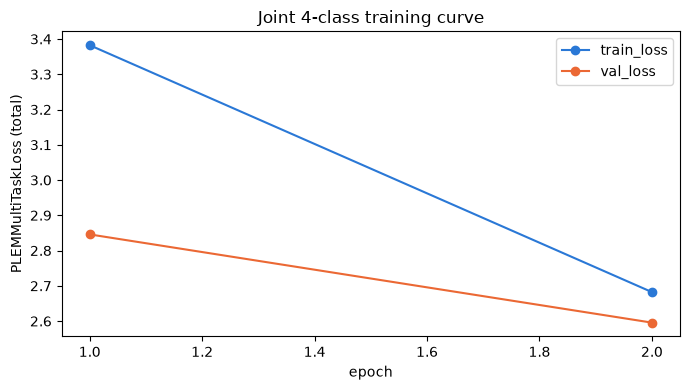

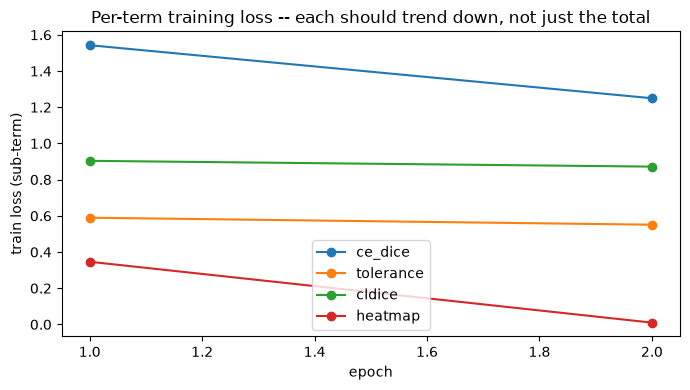

In [9]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(history["epoch"], history["train_loss"], marker="o", color="#2a78d6", label="train_loss")
ax.plot(history["epoch"], history["val_loss"], marker="o", color="#eb6834", label="val_loss")
ax.set_xlabel("epoch")
ax.set_ylabel("PLEMMultiTaskLoss (total)")
ax.set_title("Joint 4-class training curve")
ax.legend()
fig.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(7, 4))
for k in ["ce_dice", "tolerance", "cldice", "heatmap"]:
    if k in sub_term_df.columns:
        ax.plot(sub_term_df["epoch"], sub_term_df[k], marker="o", label=k)
ax.set_xlabel("epoch")
ax.set_ylabel("train loss (sub-term)")
ax.set_title("Per-term training loss -- each should trend down, not just the total")
ax.legend()
fig.tight_layout()
plt.show()

## Test-set evaluation with PLEM's metrics

Stitches per-patch predictions back into full-tile label maps (`predict_tile`) and scores each
test tile with `evaluate_all(..., point_classes=[3], dtaf1_config=<4-class config>)` -- the first
end-to-end exercise of `evaluate_all()`'s `point_classes` argument on a real trained model's
output. An explicit `dtaf1_config` is passed (rather than relying on `evaluate_all`'s default,
which only auto-fills linear/polygon entries) so DTAF1's macro average includes the point class
too, per `metrics/unified.py::evaluate_all`'s own docstring note.

In [10]:
test_rows = []
test_preds = {}

for t in test_tiles:
    pred = predict_tile(model, t["image"], t["label"].shape)
    test_preds[t["tile"]] = pred
    result = evaluate_all(
        pred, t["label"], linear_classes=[1], polygon_classes=[2], point_classes=[3],
        dtaf1_config=CLASS_CONFIG,
    )
    test_rows.append({
        "source": t["source"], "tile": t["tile"],
        "cbhm": result["cbhm"], "cbhm_soft": result["cbhm_soft"],
        "dtaf1": result["dtaf1"], "dtaf1_weighted": result["dtaf1_weighted"],
        "cldice_mean": result["cldice_mean"], "bf_mean": result["bf_mean"],
        "point_f1_mean": result["point_f1_mean"],
    })

test_results = pd.DataFrame(test_rows)
test_results.to_csv(DATA_DIR / "train_unet_joint_test_results.csv", index=False)

# Verification: point_f1_mean must be non-None for at least one real stitched
# Potsdam test-tile prediction (evaluate_all returns None only when
# point_classes isn't given -- confirm we actually exercised that path).
potsdam_point_scores = test_results.loc[test_results["source"] == "potsdam", "point_f1_mean"]
assert potsdam_point_scores.notna().any() or len(potsdam_point_scores) == 0, (
    "point_f1_mean was None for every Potsdam test tile -- evaluate_all's point_classes path "
    "was not actually exercised; check dtaf1_config/point_classes wiring above."
)
print(f"point_f1_mean non-None for {potsdam_point_scores.notna().sum()}/{len(potsdam_point_scores)} "
      f"Potsdam test tiles.")
test_results

point_f1_mean non-None for 5/5 Potsdam test tiles.


,source,tile,cbhm,cbhm_soft,dtaf1,dtaf1_weighted,cldice_mean,bf_mean,point_f1_mean
0,spacenet,Vegas_img425,0.000000,0.473836,0.300620,0.901860,0.473836,0.000000,0.0
1,spacenet,Paris_img356,0.208332,0.235840,0.536878,0.303364,0.160383,0.297180,1.0
2,spacenet,Shanghai_img756,0.198737,0.276502,0.247168,0.382856,0.133578,0.388007,0.0
3,spacenet,Shanghai_img755,0.210231,0.286402,0.229204,0.324079,0.152983,0.335944,0.0
4,spacenet,Khartoum_img230,0.074983,0.165239,0.142372,0.210842,0.045758,0.207536,0.0
5,spacenet,Vegas_img398,0.363896,0.364369,0.389343,0.574006,0.356571,0.371529,0.0
6,spacenet,Shanghai_img1170,0.007942,0.006217,0.030806,0.081540,0.006172,0.011135,0.0
7,spacenet,Vegas_img997,0.364101,0.358201,0.401692,0.654683,0.335975,0.397367,0.0
8,spacenet,Shanghai_img1523,0.083948,0.082133,0.242988,0.327631,0.047205,0.378790,0.0
9,spacenet,Vegas_img720,0.192279,0.309032,0.339928,0.662047,0.388654,0.127737,0.0


## Side-by-side comparison against the frozen CE+Dice baseline

Loads `train_unet.ipynb`'s already-saved `data/train_unet_test_results.csv` and compares against
this run's results, restricted to the SpaceNet test tiles/classes both runs share (the baseline has
no point class at all, so `point_f1_mean` has no baseline analog -- reported separately, Potsdam-
only). **This is explicitly a sanity check, not a rigorous ablation**: the two runs use different
tile-level splits (this notebook's per-source split differs from the baseline's single-source
split, so the SpaceNet test tiles aren't guaranteed identical between the two), different epoch
budgets, and different random seeds' worth of stochastic training dynamics -- a directional
comparison only. A regression here would still be worth flagging (the new loss shouldn't make
things obviously worse on classes it wasn't specifically targeting), but a small difference either
way is not a strong signal at this sample size.

In [11]:
baseline_path = DATA_DIR / "train_unet_test_results.csv"
metric_cols = ["cbhm", "cbhm_soft", "dtaf1", "dtaf1_weighted", "cldice_mean", "bf_mean"]

if baseline_path.exists():
    baseline_results = pd.read_csv(baseline_path)
    joint_spacenet = test_results[test_results["source"] == "spacenet"]
    comparison = pd.DataFrame({
        "baseline (CE+Dice, 3-class)": baseline_results[metric_cols].mean(),
        "joint (PLEMMultiTaskLoss, 4-class)": joint_spacenet[metric_cols].mean() if len(joint_spacenet) else float("nan"),
    })
    print(f"Baseline test tiles: {len(baseline_results)}  |  "
          f"Joint SpaceNet-only test tiles: {len(joint_spacenet)}")
    display(comparison)
else:
    print(f"No baseline results found at {baseline_path} -- run train_unet.ipynb first "
          f"for a side-by-side comparison.")

joint_potsdam = test_results[test_results["source"] == "potsdam"]
if len(joint_potsdam) and joint_potsdam["point_f1_mean"].notna().any():
    print(f"\nPotsdam-only point_f1_mean (no baseline analog -- baseline has no point class): "
          f"{joint_potsdam['point_f1_mean'].mean():.3f} "
          f"(n={joint_potsdam['point_f1_mean'].notna().sum()} tiles)")

No baseline results found at C:\Users\danzg\PycharmProjects\PLEM\data\train_unet_test_results.csv -- run train_unet.ipynb first for a side-by-side comparison.

Potsdam-only point_f1_mean (no baseline analog -- baseline has no point class): 0.200 (n=5 tiles)


## Qualitative review: image / GT / prediction (4-color)

Same 3-panel-per-tile layout as `train_unet.ipynb`, extended to a 4th color (yellow) for the point
class.

Vegas_img425 (spacenet):  cbhm=0.000  dtaf1=0.301  cldice_mean=0.474  bf_mean=0.000  point_f1_mean=0.000


Paris_img449 (spacenet):  cbhm=0.006  dtaf1=0.421  cldice_mean=0.151  bf_mean=0.003  point_f1_mean=1.000
Paris_img250 (spacenet):  cbhm=0.152  dtaf1=0.530  cldice_mean=0.093  bf_mean=0.412  point_f1_mean=1.000


Vegas_img997 (spacenet):  cbhm=0.364  dtaf1=0.402  cldice_mean=0.336  bf_mean=0.397  point_f1_mean=0.000


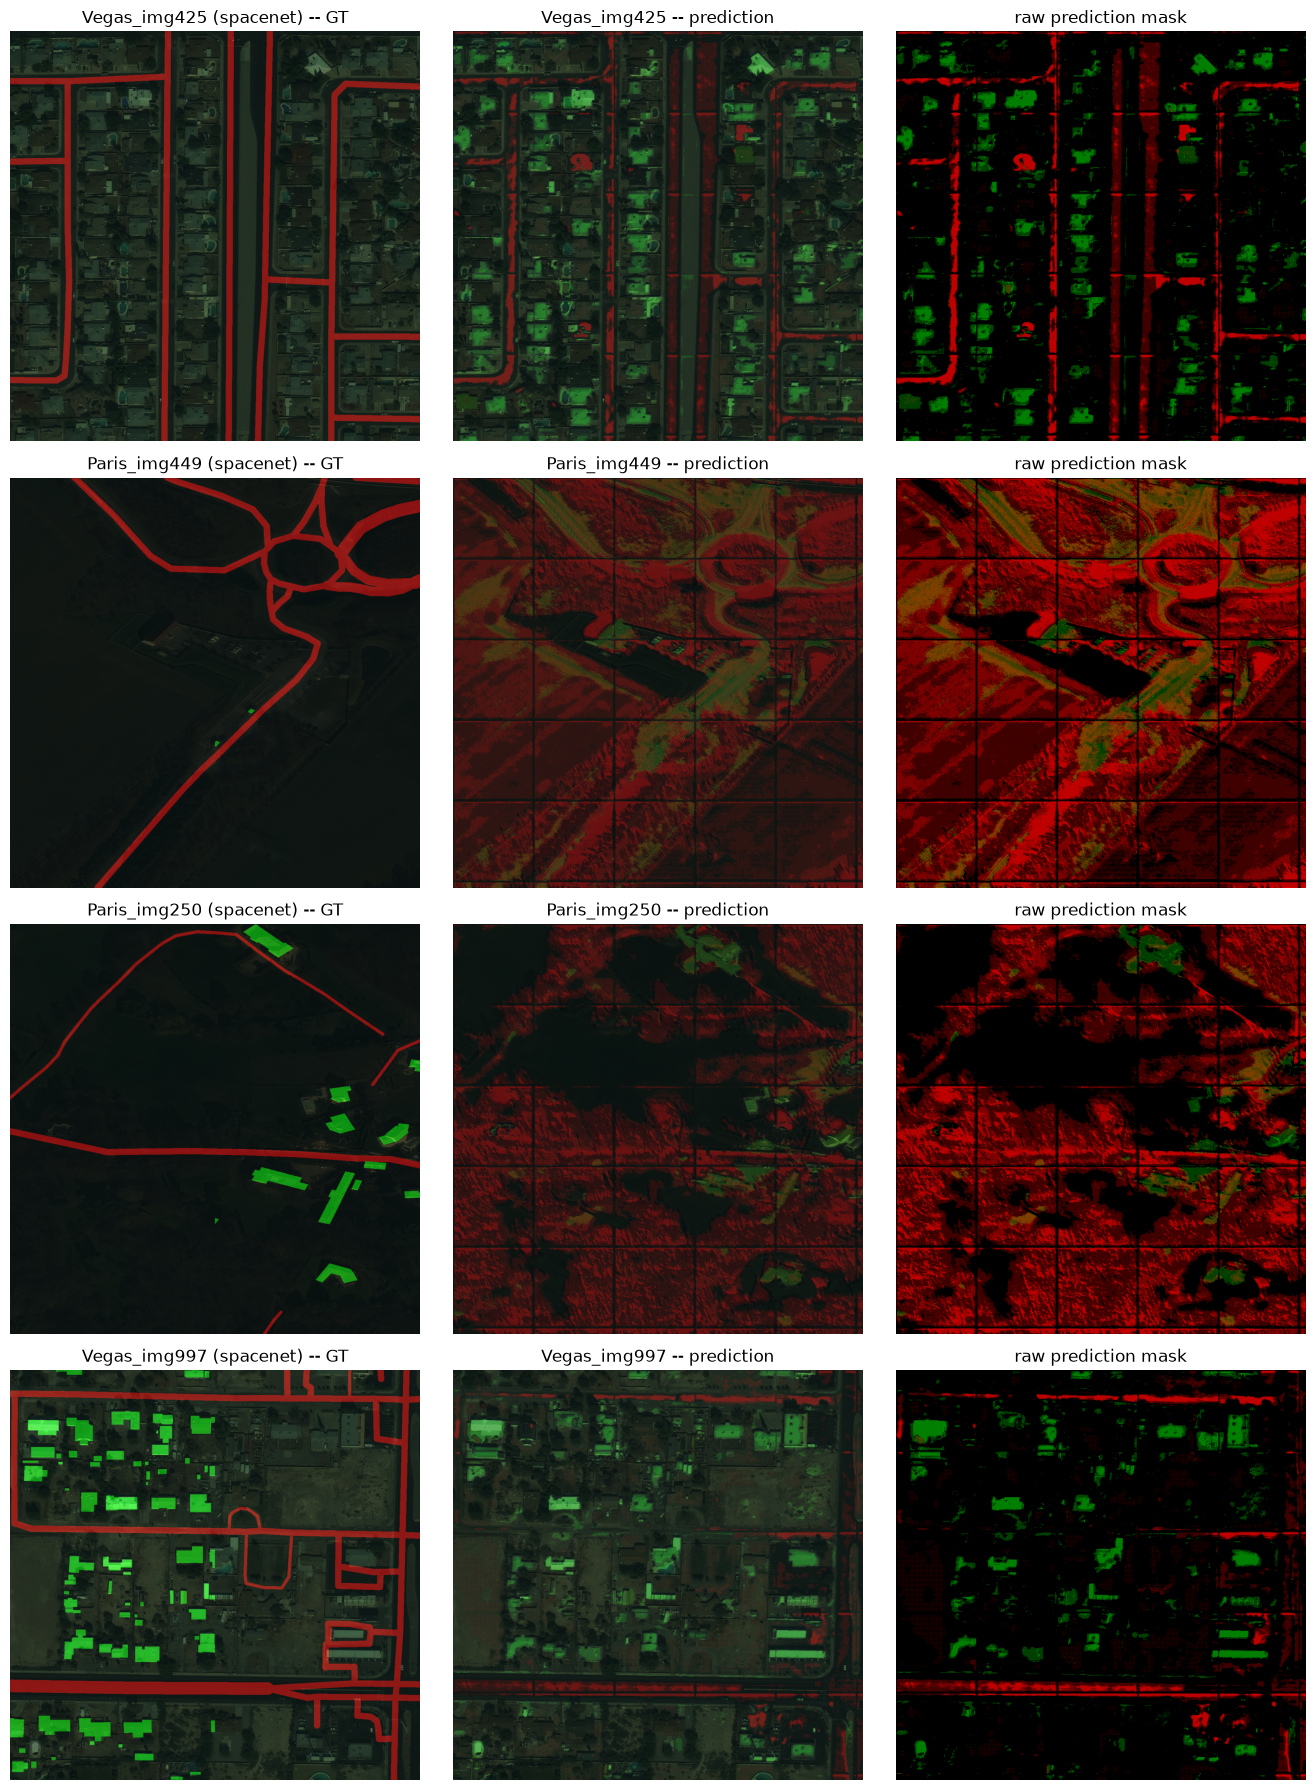

In [12]:
N_EXAMPLES = min(4, len(test_tiles))
example_order = test_results.sort_values("cbhm")["tile"].tolist()
example_stems = [example_order[i] for i in np.linspace(0, len(example_order) - 1, N_EXAMPLES).round().astype(int)]
tiles_by_stem = {t["tile"]: t for t in test_tiles}

fig, axes = plt.subplots(N_EXAMPLES, 3, figsize=(13.5, 4.5 * N_EXAMPLES))
if N_EXAMPLES == 1:
    axes = axes[None, :]

for row, stem in enumerate(example_stems):
    t = tiles_by_stem[stem]
    gt, pred, image = t["label"], test_preds[stem], t["image"]
    scores = test_results.loc[test_results["tile"] == stem].iloc[0]

    axes[row, 0].imshow(image)
    axes[row, 0].imshow(overlay4(gt), alpha=0.5)
    axes[row, 0].set_title(f"{stem} ({t['source']}) -- GT")
    axes[row, 1].imshow(image)
    axes[row, 1].imshow(overlay4(pred), alpha=0.5)
    axes[row, 1].set_title(f"{stem} -- prediction")
    axes[row, 2].imshow(overlay4(pred))
    axes[row, 2].set_title("raw prediction mask")
    for col in range(3):
        axes[row, col].axis("off")

    pf1 = scores["point_f1_mean"]
    pf1_str = f"{pf1:.3f}" if pd.notna(pf1) else "n/a"
    print(f"{stem} ({t['source']}):  cbhm={scores['cbhm']:.3f}  dtaf1={scores['dtaf1']:.3f}  "
          f"cldice_mean={scores['cldice_mean']:.3f}  bf_mean={scores['bf_mean']:.3f}  "
          f"point_f1_mean={pf1_str}")

fig.tight_layout()
plt.show()

## Observations

- First genuinely joint 0D/1D/2D training run in PLEM: a single 4-class model trained on two
  heterogeneous, single-modality real sources (SpaceNet: road+building; Potsdam: building+point)
  via `PLEMMultiTaskLoss`'s masked multi-source scheme, evaluated end-to-end with
  `evaluate_all(..., point_classes=[3])` on real stitched predictions -- the first time that
  argument has ever been exercised on a real trained model's output rather than left `None`.
- **Explicit pipeline-sanity-check framing, matching `train_unet.ipynb`'s own posture**: reduced
  epoch budget, a small and heterogeneous combined dataset (~100 SpaceNet tiles + ~15 Potsdam
  crops at two different GSDs, not resampled to a common one), and a baseline comparison that is
  directional only (different splits/seeds between the two runs) -- treat all numbers above as
  "does the mechanism work," not "is the new loss better."
- If a sub-term's per-epoch value stays flat near its starting value while the total still drops,
  that specific term is not learning (other terms are dominating the gradient) -- worth
  investigating its `weights` entry in `PLEMMultiTaskLoss` before trusting that term's contribution
  to the final model.
- See `PAPER_OUTLINE.md` §9.5/§10.5/§11 for how this run's results (once inspected) should be
  written up, and §11's discussion of the SpaceNet/Potsdam GSD mismatch and the heatmap term's
  differing loss magnitude -- both directly relevant to interpreting the numbers above.